In [1]:
import os

os.environ["OPENAI_API_KEY"] = "sk-19fe6b9376f8473bab1defd0bde82559"

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
#     model="qwen3.5-plus-2026-02-15",
#     model="qwen3.5-plus",
#     model="glm-5.1",
    model="kimi-k2.5",
    temperature=0,
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)

In [3]:
import re
import pdfplumber
from langchain_core.documents import Document
from sqlalchemy.types import String, Integer, Numeric

def clean_text(text):
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

def normalize_text(s):
    if s is None:
        return ""
    s = str(s)
    s = s.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    s = s.replace("（", "(").replace("）", ")")
    s = s.replace("：", ":")
    s = s.replace("，", ",")
    s = s.replace("“", '"').replace("”", '"')
    s = s.replace("‘", "'").replace("’", "'")
    s = re.sub(r"\s+", " ", s).strip()
    return s

TABLE_DTYPE_MAP = {
    "core": {
        "stock_code": String(6),
    },
    "balance": {
        "stock_code": String(6),
    },
    "cash": {
        "stock_code": String(6),
    },
    "income": {
        "stock_code": String(6),
    },
}

In [4]:
import re
import pandas as pd
from sqlalchemy import create_engine
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from sqlalchemy.types import String

engine = create_engine("sqlite:///example.db")

def normalize_stock_code(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s:
        return None
    s = re.sub(r"\.0+$", "", s)
    if s.isdigit():
        s = s.zfill(6)
    return s

def cast_df_by_table(df, table_name):
    df = df.copy()
    dtype_map = TABLE_DTYPE_MAP.get(table_name, {})

    for col, sql_type in dtype_map.items():
        if col not in df.columns:
            continue

        if isinstance(sql_type, String):
            if col == "stock_code":
                df[col] = df[col].apply(normalize_stock_code).astype("string")
            else:
                df[col] = df[col].astype("string")

    return df

sheets = pd.read_excel(
    r"final_result_final.xlsx",
    sheet_name=None,
    engine="openpyxl"
)

for sheet_name, df in sheets.items():
    table_name = sheet_name.strip().replace(" ", "_").replace("-", "_")

    df = cast_df_by_table(df, table_name)

    dtype_map = {
        col: sql_type
        for col, sql_type in TABLE_DTYPE_MAP.get(table_name, {}).items()
        if col in df.columns
    }

    df.to_sql(
        table_name,
        con=engine,
        if_exists="replace",
        index=False,
        dtype=dtype_map if dtype_map else None
    )

db = SQLDatabase.from_uri("sqlite:///example.db")
print(db.get_usable_table_names())

['balance', 'cash', 'core', 'income', 'other']


In [5]:
import os
import requests, pathlib
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_openai import ChatOpenAI
import numpy as np

from langchain.messages import AIMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

from typing_extensions import TypedDict, Required
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from typing import List, Dict, Any, Literal, Annotated
from pydantic import BaseModel, Field
from pydantic import BaseModel, Field
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class ParentState(MessagesState, total=False):
    query: Required[str]
        
    real_query: str

    route: Literal["sql", "clarify"]
    reason: str
    missing_slots: List[str] = []

    need_sql: bool
    need_clarification: bool

    sql_result: dict

    final_answer: str
    
    summary: str
        
    sql_query: str
    sql_answer: str
        
    sql_messages: Annotated[list[AnyMessage], add_messages]
        
    question_count: int
    skip_summary: bool

In [6]:
def merge_query(state: ParentState):
    query = state["query"] or state["messages"][-1].content
    summary = state.get("summary", "")
    
    if summary == "":
        return {
        "real_query": query,
        }
    
    prompt = f"""
    
    你是一个对话查询改写助手。你的任务是根据“历史对话摘要 summary”和“用户当前输入 query”，判断用户这一轮真正想问的问题，并输出一个完整、明确、可独立理解的 query。

    请严格遵循以下规则：

    1. 如果当前 query 本身已经完整明确，不依赖历史上下文，就直接原样返回，不要过度改写。
    2. 如果当前 query 中出现了代词、指代、省略、延续上文的表达（例如“它”“这个”“刚才那个”“继续”“再详细一点”“那数据库里的呢”），就结合 summary 补全成一个完整明确的问题。
    3. 改写后的 query 必须保留用户原本意图，不能擅自增加新需求，也不能改变问题方向。
    4. 优先补全以下信息：
       - 当前问的是哪个对象
       - 当前问的是哪个任务/主题
       - 是否是在上一轮结果基础上继续追问
       - 是否有输出格式、范围、限制条件
    5. 如果 summary 与当前 query 无明显关系，则以当前 query 为准。
    6. 输出必须简洁，只输出“最终 query”本身，不要输出解释，不要输出分析过程，不要加引号。

    历史对话摘要 summary：
    {summary if summary else "（无历史摘要）"}

    用户当前输入 query：
    {query}

    请输出用户这一轮真正的完整 query：
    
    """
    
    real_query = llm.invoke([{"role": "user", "content": prompt}]).content.strip()
    
    return {
        "real_query": real_query,
    }

In [7]:
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
tools = toolkit.get_tools()

get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")
get_schema_node = ToolNode([get_schema_tool], name="get_schema", messages_key="sql_messages")

run_query_tool = next(tool for tool in tools if tool.name == "sql_db_query")
run_query_node = ToolNode([run_query_tool], name="run_query", messages_key="sql_messages")

In [8]:
def list_tables(state: ParentState):
    
    usable_tables = list(db.get_usable_table_names())
    
    query = state["real_query"]
    

    prompt = f"""
    
    你需要为后续 SQL 查询选择最相关的表，并调用 sql_db_schema 获取 schema。

    当前数据库可选表只有：
    {usable_tables}

    重要说明：
    - 只能从上面的真实表名中选择，严禁臆造表名，例如 financial_metrics、financial_data、metrics 等。
    - 必须选择 1~3 张最相关的表，不能返回空列表。
    - 不要直接回答用户问题，只做“选表 + 调用 sql_db_schema”。
    - 如果问每股收益，优先考虑 core
    - 如果问营业利润、利润总额、营业总支出、销售费用、管理费用、财务费用、研发费用等利润表项目，优先考虑 income
    - 如果问资产、负债、权益、存货、应收账款，优先考虑 balance
    - 如果问经营、投资、融资现金流，优先考虑 cash
    - 如果问营业总收入或净利润：指标分析优先 core，报表项目金额优先 income

    当前问题：{query}
    """
    
    
    llm_with_tools = llm.bind_tools([get_schema_tool], tool_choice="any")
    response = llm_with_tools.invoke([HumanMessage(content=prompt)])

    return {"sql_messages": [response]}

def call_get_schema(state: ParentState):
    llm_with_tools = llm.bind_tools([get_schema_tool], tool_choice="any")
    response = llm_with_tools.invoke(state["sql_messages"])

    return {"sql_messages": [response]}

generate_query_system_prompt = """
你是一个专为与 SQL 数据库交互而设计的智能体。
给定一个用户输入问题，请生成一条语法正确的 {dialect} 查询语句并执行，
然后查看查询结果并返回答案。除非用户明确指定了希望获取的示例数量，否则始终将你的查询结果限制在最多 {top_k} 条。

你可以按相关列对结果进行排序，以返回数据库中最有趣的示例。切勿查询特定表的所有列，仅根据问题请求相关的列。

对于趋势/可视化类问题（例如：趋势、变化、走势、近几年、近年、历年、近年来、多年、可视化、绘图、折线图、柱状图）：
1. 返回时间序列查询，而非单个标量结果。
2. 选择一个时间列和一个数值指标列。
3. 优先保留原始字段名，除非确有必要，否则不要统一别名为 x_axis 和 y_axis。
4. 按时间顺序升序排列结果。
5. 不要机械地应用默认的 top_k 限制；应保留绘图所需的所有时间段。

【时间粒度选择规则】
A. 如果问题是“跨年度趋势”，例如包含：
“近几年、近年、历年、近年来、多年”，并且语义是在问整体趋势/变化/走势，
那么：
- 优先使用 report_year 作为时间轴；
- 如果表中存在 report_period 字段，则只保留年度口径数据；
- 年度口径优先匹配 FY、年度、年报、12-31、1231、年末 这类含义；
- 不要同时返回 Q1、HY、Q3、FY 等多种期间；
- 最终结果必须保证每个 report_year 最多一条记录。

B. 如果问题是“某一年内的季度/期间变化”，例如包含：
“各季度、分季度、季度变化、Q1、Q3、半年报、三季报、某年内变化”，
那么：
- 不要只用 report_year 作为时间轴；
- 应优先使用 report_period，必要时将 report_year 和 report_period 拼接成一个唯一时间标签；
- 结果可按 Q1 < H1 < Q3 < FY 的顺序排序；
- 同一时间标签只能保留一条记录。

C. 如果用户明确说“按年度看”“年度趋势”，按规则 A 处理。
D. 如果用户明确说“按季度看”“分季度看”，按规则 B 处理。

【指标字段优先级规则】
1. 当用户明确问“同比增长率”“环比增长率”“增长率”时：
   - 如果 schema 中存在对应的现成增长率字段，必须优先直接查询该字段；
   - 不要改查原始金额字段后再自行计算。
2. 典型映射如下：
   - 营业总收入环比增长率 / 营业收入环比增长率 / 营收环比增长率 -> operating_revenue_qoq_growth
   - 营业总收入同比增长率 / 营业收入同比增长率 / 营收同比增长率 -> operating_revenue_yoy_growth
   - 净利润环比增长率 / 归母净利润环比增长率 -> net_profit_qoq_growth
   - 净利润同比增长率 / 归母净利润同比增长率 -> net_profit_yoy_growth
   - 总资产同比增长率 -> asset_total_assets_yoy_growth
   - 总负债同比增长率 -> liability_total_liabilities_yoy_growth
3. 只有当对应增长率字段不存在时，才允许改查原始金额字段并自行计算。

【累计口径转单季规则】
1. 财报中的 HY、FY 往往是累计值，不一定是单季值。
2. 若必须根据原始金额自行计算单季值，必须使用以下规则：
   - Q1单季 = Q1累计
   - Q2单季 = H1累计 - Q1累计
   - Q3单季 = Q3累计
   - Q4单季 = FY累计 - H1累计 - Q3累计
3. 若问题要求“环比增长率”，必须先转成单季值，再计算环比：
   - Q2环比 = (Q2单季 - Q1单季) / Q1单季
   - Q3环比 = (Q3单季 - Q2单季) / Q2单季
   - Q4环比 = (Q4单季 - Q3单季) / Q3单季
4. 禁止把累计值直接拿去和上一季度累计值做环比。

【显式期间过滤规则】
1. 如果问题明确指定了目标期间，例如“2025年第三季度与2024年第三季度相比”，最终返回结果必须只保留这两个目标期间对应的结果。
2. 如果为了中间计算需要额外用到 Q1、H1、Q3、FY 等期间，可以在 CTE 或子查询中使用；
   但最终 SELECT 不要把无关期间（如 FY、Q1）返回给用户。
3. 对于“请展示两年同期的环比数据”这类问题，最终结果应类似：
   report_year, report_period, operating_revenue_qoq_growth
   2024, Q3, ...
   2025, Q3, ...

【结果唯一性要求】
- 若时间轴是 report_year，则每个 report_year 只能出现一行。
- 若时间轴是 report_period 或拼接时间标签，则每个时间标签只能出现一行。
- 如底层原始表中同一年存在多条候选记录，优先保留年度口径；若无年度口径，再保留该年最后一个可用期间。

切勿对数据库执行任何 DML 语句（如 INSERT、UPDATE、DELETE、DROP 等）。

【股票代码字段规则】
- stock_code 一律按字符串处理，不要按数字处理。
- 查询股票代码时，必须使用带引号的 6 位代码，例如 '000538'、'600436'。
- 不要写成 stock_code = 538 或 stock_code = 600436。
- 如果结果中需要返回股票代码，优先直接返回原始 stock_code 字段，不要做数值运算。

如果上下文中已经给出了所需表的 schema，请不要再次调用 sql_db_schema 或 sql_db_list_tables。
此阶段只允许两种行为：
1. 生成并调用 sql_db_query；
2. 在已有查询结果时直接输出最终答案。

【最终回答格式要求】
1. 只输出纯文本，不要使用 Markdown。
2. 不要使用表格语法，如 |---|、| 列 |。
3. 不要使用 **粗体**、# 标题、- 列表。
4. 严禁输出字面量字符“\\n”、“\\t”以及任何其他转义字符。
5. 先给结论，再给必要说明。
6. 输出内容要适合直接写入 Excel 单元格。
7. 如果问题属于趋势/变化/走势/历年分析类，不要只给一句笼统结论，必须结合查询结果展开说明。
8. 对于趋势类问题，回答中尽量包含以下信息：
   总体趋势判断；各时间段关键数值变化；相邻时期增减变化；全周期累计变化幅度；如连续增长或连续下降要明确指出。
9. 如果查询结果是多期时间序列，回答不少于3句，避免只输出一句压缩总结。
10. 回答仍然使用纯文本，但可以分句清晰表达，不要过度简写。
11. 严禁输出任何思考过程、推理过程、自言自语、计划性语句。
12. 严禁出现类似：
    Now I have..., Let me..., I will..., First, ...
    我先..., 下面我来..., 让我先..., 接下来我...
13. 不要描述你正在查看数据或接下来要做什么，只直接输出面向用户的最终答案。
""".format(
    dialect=db.dialect,
    top_k=5,
)
###
def has_tool_result(messages, tool_name: str) -> bool:
    target = normalize_tool_call({"name": tool_name, "args": {}})["name"]
    for m in messages:
        if getattr(m, "type", None) == "tool":
            m_name = normalize_tool_call({"name": getattr(m, "name", ""), "args": {}})["name"]
            if m_name == target:
                return True
    return False

# def compact_sql_messages(messages):
#     latest_user = None
#     latest_schema_pair = []
#     latest_query_pair = []

#     i = 0
#     while i < len(messages):
#         m = messages[i]

#         if isinstance(m, HumanMessage):
#             latest_user = m

#         tool_calls = getattr(m, "tool_calls", None) or []

#         if tool_calls:
#             for raw_tc in tool_calls:
#                 tc = normalize_tool_call(raw_tc)
#                 tool_name = tc.get("name")
#                 tool_id = raw_tc.get("id")

#                 pair = [m]

#                 if i + 1 < len(messages):
#                     nxt = messages[i + 1]
#                     nxt_type = getattr(nxt, "type", None)
#                     nxt_tool_call_id = getattr(nxt, "tool_call_id", None)
#                     nxt_name = getattr(nxt, "name", None)

#                     if nxt_type == "tool" and (
#                         nxt_tool_call_id == tool_id or nxt_name == tool_name
#                     ):
#                         pair.append(nxt)

#                 if tool_name == "sql_db_schema":
#                     latest_schema_pair = pair
#                 elif tool_name == "sql_db_query":
#                     latest_query_pair = pair

#         i += 1

#     compacted = []
#     if latest_user is not None:
#         compacted.append(latest_user)
#     compacted.extend(latest_schema_pair)
#     compacted.extend(latest_query_pair)

#     return compacted
def compact_sql_messages(messages):
    latest_user = None
    latest_schema_pair = []
    query_pairs = []

    i = 0
    while i < len(messages):
        m = messages[i]

        if isinstance(m, HumanMessage):
            latest_user = m

        tool_calls = getattr(m, "tool_calls", None) or []

        if tool_calls:
            for raw_tc in tool_calls:
                tc = normalize_tool_call(raw_tc)
                tool_name = tc.get("name")
                tool_id = raw_tc.get("id")

                pair = [m]

                if i + 1 < len(messages):
                    nxt = messages[i + 1]
                    nxt_type = getattr(nxt, "type", None)
                    nxt_tool_call_id = getattr(nxt, "tool_call_id", None)
                    nxt_name = getattr(nxt, "name", None)

                    if nxt_type == "tool" and (
                        nxt_tool_call_id == tool_id or nxt_name == tool_name
                    ):
                        pair.append(nxt)

                if tool_name == "sql_db_schema":
                    latest_schema_pair = pair
                elif tool_name == "sql_db_query":
                    query_pairs.append(pair)

        i += 1

    compacted = []
    if latest_user is not None:
        compacted.append(latest_user)
    compacted.extend(latest_schema_pair)

    # 保留最近 3 组 query pair，而不是只保留最后 1 组
    for pair in query_pairs[-3:]:
        compacted.extend(pair)

    return compacted

def generate_query(state: ParentState):
    query = state["real_query"]

    system_message = {
        "role": "system",
        "content": generate_query_system_prompt + f"""

补充上下文：
- 用户输入问题：{query}
- 当前阶段严禁调用 sql_db_list_tables
- 当前阶段严禁再次调用 sql_db_schema
- 如果需要工具调用，唯一允许调用的工具是 sql_db_query
- 如果已经有 sql_db_query 的执行结果，则不要再调用任何工具，直接输出最终答案
"""
    }

    compact_messages = compact_sql_messages(state["sql_messages"])
    has_query_result = has_tool_result(compact_messages, "sql_db_query")
    
    user_message = HumanMessage(content=query)

    if has_query_result:
        response = llm.invoke([system_message, user_message] + compact_messages)
        return {"sql_messages": [response]}

    llm_with_tools = llm.bind_tools([run_query_tool], tool_choice="any")
    response = llm_with_tools.invoke([system_message, user_message] + compact_messages)

    tool_calls = getattr(response, "tool_calls", None) or []
    if tool_calls:
        tc = normalize_tool_call(tool_calls[0])
        if tc.get("name") != "sql_db_query":
            print(f"[warn] generate_query 阶段模型错误调用了 {tc.get('name')}，正在强制重试")
            retry_msg = HumanMessage(content="只能调用 sql_db_query。不要调用 sql_db_schema，不要调用 sql_db_list_tables。")
            response = llm_with_tools.invoke([system_message, user_message] + compact_messages + [retry_msg])

    return {"sql_messages": [response]}

In [9]:
def normalize_tool_call(tool_call):
    tc = dict(tool_call or {})
    raw_name = str(tc.get("name") or "").strip()
    args = tc.get("args", {}) or {}

    # args 有时可能直接是字符串
    if isinstance(args, str):
        args = {"query": args}

    # 先处理 \x00 分隔的脏格式
    parts = [p for p in raw_name.split("\x00") if p != ""]
    base_name = parts[0] if parts else raw_name

    if base_name.startswith("sql_db_query"):
        if len(parts) >= 3 and not args:
            key = parts[1].strip()
            value = "\x00".join(parts[2:]).strip()
            if key:
                args = {key: value}
        base_name = "sql_db_query"

    elif base_name.startswith("sql_db_schema"):
        base_name = "sql_db_schema"

    elif base_name.startswith("sql_db_list_tables"):
        base_name = "sql_db_list_tables"

    tc["name"] = base_name
    tc["args"] = args
    return tc


def extract_sql_from_tool_call(tool_call):
    tc = normalize_tool_call(tool_call)
    args = tc.get("args", {}) or {}

    if isinstance(args, str):
        return args.strip()

    for key in ("query", "__arg1", "input", "sql"):
        value = args.get(key)
        if isinstance(value, str) and value.strip():
            return value.strip()

    return None

In [10]:
def extract_table_names_from_tool_call(tool_call):
    tool_call = normalize_tool_call(tool_call)
    args = tool_call.get("args", {}) or {}
    table_names = args.get("table_names") or args.get("__arg1") or []

    if isinstance(table_names, str):
        table_names = table_names.replace("，", ",")
        table_names = [x.strip() for x in table_names.split(",") if x.strip()]

    if table_names is None:
        table_names = []

    return table_names

# def should_continue(state: ParentState) -> Literal["run_query", "get_schema", END]:
#     last_message = state["sql_messages"][-1]
#     tool_calls = getattr(last_message, "tool_calls", None) or []

#     if not tool_calls:
#         print("[should_continue] no tool_calls -> END")
#         return END

#     raw_tc = tool_calls[0]
#     print("[should_continue] raw tool_call =", raw_tc)

#     tool_call = normalize_tool_call(raw_tc)
#     print("[should_continue] normalized tool_call =", tool_call)

#     raw_name = (raw_tc.get("name") or "").strip()
#     tool_name = (tool_call.get("name") or "").strip()

#     print("[should_continue] raw name =", raw_name)
#     print("[should_continue] normalized name =", tool_name)

#     if tool_name == "sql_db_query":
#         print("[should_continue] -> run_query")
#         return "run_query"

#     if tool_name == "sql_db_schema":
#         table_names = extract_table_names_from_tool_call(tool_call)
#         print("[should_continue] schema table_names =", table_names)

#         if table_names:
#             print("[should_continue] -> get_schema")
#             return "get_schema"

#         print(f"[warn] sql_db_schema 的 table_names 为空: {tool_call}")
#         return END

#     print(f"[warn] generate_query 返回了未预期的工具调用: {tool_calls}")
#     return END
def should_continue(state: ParentState) -> Literal["run_query", "get_schema", END]:
    last_message = state["sql_messages"][-1]
    tool_calls = getattr(last_message, "tool_calls", None) or []

    if not tool_calls:
        return END

    tool_call = normalize_tool_call(tool_calls[0])
    tool_name = (tool_call.get("name") or "").strip()

    if tool_name == "sql_db_query":
        return "run_query"

    if tool_name == "sql_db_schema":
        table_names = extract_table_names_from_tool_call(tool_call)
        if table_names:
            return "get_schema"

        print(f"[warn] sql_db_schema 的 table_names 为空: {tool_call}")
        return END

    print(f"[warn] generate_query 返回了未预期的工具调用: {tool_calls}")
    return END

builder = StateGraph(ParentState)
builder.add_node(list_tables)
builder.add_node(get_schema_node, "get_schema")
builder.add_node(generate_query)
builder.add_node(run_query_node, "run_query")

builder.add_edge(START, "list_tables")
builder.add_edge("list_tables", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_conditional_edges(
    "generate_query",
    should_continue,
    {
        "run_query": "run_query",
        "get_schema": "get_schema",
        END: END,
    },
)
builder.add_edge("run_query", "generate_query")

sql_graph = builder.compile()
# def should_continue(state: ParentState) -> Literal["check_query", "get_schema", END]:
#     last_message = state["sql_messages"][-1]
#     tool_calls = getattr(last_message, "tool_calls", None) or []

#     if not tool_calls:
#         return END

#     tool_call = tool_calls[0]
#     tool_name = tool_call.get("name")

#     if tool_name == "sql_db_query":
#         return "check_query"

#     if tool_name == "sql_db_schema":
#         table_names = extract_table_names_from_tool_call(tool_call)
#         if table_names:
#             return "get_schema"

#         print(f"[warn] sql_db_schema 的 table_names 为空: {tool_call}")
#         return END

#     print(f"[warn] generate_query 返回了未预期的工具调用: {tool_calls}")
#     return END

# builder = StateGraph(ParentState)
# builder.add_node(list_tables)
# builder.add_node(get_schema_node, "get_schema")
# builder.add_node(generate_query)
# builder.add_node(check_query)
# builder.add_node(run_query_node, "run_query")

# builder.add_edge(START, "list_tables")
# builder.add_edge("list_tables", "get_schema")
# builder.add_edge("get_schema", "generate_query")
# builder.add_conditional_edges(
#     "generate_query",
#     should_continue,
#     {
#         "check_query": "check_query",
#         "get_schema": "get_schema",
#         END: END,
#     },
# )
# builder.add_edge("check_query", "run_query")
# builder.add_edge("run_query", "generate_query")

# sql_graph = builder.compile()

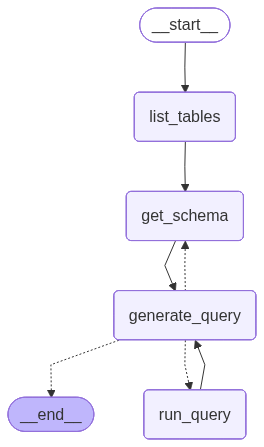

In [11]:
from IPython.display import Image, display

display(Image(sql_graph.get_graph().draw_mermaid_png()))

In [11]:
def format_messages_as_text(messages):
    lines = []

    for msg in messages:
        if isinstance(msg, dict):
            role = msg.get("role", "unknown")
            content = msg.get("content", "")
        else:
            msg_type = getattr(msg, "type", "unknown")
            content = getattr(msg, "content", "")

            if msg_type == "human":
                role = "user"
            elif msg_type == "ai":
                role = "assistant"
            else:
                role = msg_type

        lines.append(f"{role}: {content}")

    return "\n".join(lines)

def summarize(state: ParentState):
    if state.get("skip_summary", False):
        return {}
    
    messages = state.get("messages", [])
    latest_turn = messages[-2:] if len(messages) >= 2 else messages
    latest_turn_text = format_messages_as_text(latest_turn)
    old_summary = state.get("summary", "")
    
    summarize_prompt = f"""
    
        你是一个负责维护多轮对话记忆的模块。
        
        请基于【历史记忆】和【最新对话】，更新记忆。
        只保留对后续任务推进有价值的信息。
        
        记忆中只保留：
        - 用户当前目标
        - 已确认的关键信息
        - 用户偏好与限制
        - 尚未解决的问题
        - 下一步应做的事

        请遵守：
        - 不要复述原始对话
        - 不要保留寒暄、客套、重复内容
        - 若新旧信息冲突，以最新且明确确认的信息为准
        - 未确认内容单独标注，不要当作事实
        - 删除过时信息
        - 不要编造任何未出现的信息
        - 回答最多使用五句话，并保持简洁。

        【历史信息】
        {old_summary}

        【最新对话】
        {latest_turn_text}
        
    """
    
    summarize_history = llm.invoke([{"role": "user", "content": summarize_prompt}]).content.strip()
    
    print("-"*100)
    print("Summary")
    print(summarize_history)
    print("-"*100)
    
    return {
        "summary": summarize_history,
    }

In [12]:
class RouteDecision(BaseModel):
    route: Literal["sql", "clarify"] = Field(
        description="The routing decision for the user query."
    )
    reason: str = Field(
        description="One-sentence reason for the routing decision."
    )
    missing_slots: List[str] = Field(
        default_factory=list,
        description="Missing required slots such as company, period, metric. Empty list if none."
    )

def route_node(state: ParentState):
    question = state["real_query"]
    
    route_prompt = f"""
    
    你是一个上市公司财报智能问数助手的“路由器（Router）”。

    你的任务不是回答用户问题，而是判断这个问题应该走哪条处理链路。

    你只能输出以下两种 route：
    1. sql
       - 适用于可以主要通过结构化财务数据库回答的问题
       - 典型包括：数值查询、指标查询、同比/环比、趋势、排名、topN、筛选、排序、聚合统计、跨公司比较
    2. clarify
       - 适用于用户问题缺少关键条件，当前无法可靠执行
       - 例如缺少公司名、报告期、指标名、比较对象等
    
    判定原则：
    - 如果问题主要在问“多少、是否、排名、变化趋势、同比环比、topN、哪个最大/最小”，优先判为 sql
    - 如果问题缺少关键查询条件，判为 clarify

    请特别注意：
    - “趋势分析”“同比分析”“排名分析”通常仍然属于 sql

    示例1
    用户问题：比亚迪2025年三季度营业收入是多少？
    输出：
    {{
      "route": "sql",
      "reason": "这是明确的单指标单时期数值查询，可直接通过结构化财务数据库回答",
      "missing_slots": [],
    }}

    示例2
    用户问题：金花股份近几年的利润总额变化趋势是什么样的？
    输出：
    {{
      "route": "sql",
      "reason": "这是时间序列趋势分析问题，主要依赖结构化财务数据",
      "missing_slots": [],
    }}

    示例3
    用户问题：利润总额是多少？
    输出：
    {{
      "route": "clarify",
      "reason": "缺少公司和报告期，无法直接执行查询",
      "missing_slots": ["company", "period"],
    }}
    
    示例4
    用户问题：华为每股收益是多少？
    输出：
    {{
      "route": "clarify",
      "reason": "缺少报告期，无法直接执行查询",
      "missing_slots": ["period"],
    }}
    
    现在请判断下面这个用户问题：
    用户问题：{question}

    请严格输出 JSON，不要输出任何额外解释：
    
    {{
      "route": "sql | clarify",
      "reason": "一句话说明分类原因",
      "missing_slots": [],
    }}
    """
    structured_llm = llm.with_structured_output(RouteDecision)
    decision = structured_llm.invoke(route_prompt)
    
    return {
        "real_query": question,
        "route": decision.route,
        "reason": decision.reason,
        "missing_slots": decision.missing_slots,
        "need_sql": decision.route == "sql",
        "need_clarification": decision.route == "clarify",
        "final_answer": "",
    }
    
def route_function(state: ParentState):
    key = state.get("route")
    if key == "sql":
        return "sql_node"
    else:
        return "clarify"

In [13]:
def clarify(state: ParentState):
    question = state["real_query"]
    missing_slots = state.get("missing_slots", [])

    clarify_prompt = f"""
        你是一个上市公司财报智能问数助手。

        用户原始问题：
        {question}

        当前还缺少这些关键信息：
        {missing_slots}

        你的任务是：
        基于用户原始问题和缺失槽位，生成一句自然、简洁、礼貌的澄清问题，引导用户一次性补全所缺信息，以便继续查询。

        要求：
        1. 只输出一句面向用户的澄清问题，不要输出解释，不要输出 JSON，不要输出多余内容。
        2. 如果缺少多个槽位，尽量合并成一句话一起问，不要拆成多句。
        3. 语气自然，适合中文对话场景。
        4. 问法要贴合财报问数场景。
        
        示例1
        原始问题：利润总额是多少？
        缺失槽位：["company", "period"]
        输出：请问你想查询哪家公司，以及哪个报告期的利润总额？

        示例2
        原始问题：同比最高的是哪家？
        缺失槽位：["metric", "period", "ranking_scope"]
        输出：请问你想查询哪个指标、哪个报告期，以及希望在哪个范围内比较同比？

        示例3
        原始问题：原因是什么？
        缺失槽位：["explanation_target"]
        输出：请问你具体想了解哪个指标或现象变化的原因？
        """.strip()

    response = llm.invoke([{"role": "user", "content": clarify_prompt}])

    return {
        "messages": [AIMessage(content=response.content)],
        "final_answer": response.content,
        "need_clarification": True,
        "pending_clarification": True,
        "original_question": question,
        "missing_slots": missing_slots,
    }

In [14]:
from typing import Literal
from pydantic import BaseModel, Field
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker
import textwrap

# class ChartDecision(BaseModel):
#     need_chart: bool = Field(description="是否需要画图")
#     chart_type: Literal["table", "line", "bar", "pie", "none"]
#     x_col: str = ""
#     y_col: str = ""
#     series_col: str = ""
#     title: str = ""
#     reason: str = ""
class ChartDecision(BaseModel):
    need_chart: bool = Field(description="是否需要画图")
    chart_type: Literal[
        "table",
        "line",
        "bar",
        "double_bar",
        "scatter",
        "hist",
        "pie",
        "box",
        "radar",
        "none"
    ]
    x_col: str = ""
    y_col: str = ""
    y_col2: str = ""
    series_col: str = ""
    title: str = ""
    reason: str = ""

def configure_matplotlib_chinese():
    candidate_fonts = [
        "SimHei",
        "Microsoft YaHei",
        "STHeiti",
        "PingFang SC",
        "Noto Sans CJK SC",
        "WenQuanYi Zen Hei",
        "Arial Unicode MS"
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    chosen = None
    for f in candidate_fonts:
        if f in available:
            chosen = f
            break

    if chosen:
        plt.rcParams["font.sans-serif"] = [chosen]
    else:
        print("警告：未检测到常见中文字体，图表中文可能显示异常。")

    plt.rcParams["axes.unicode_minus"] = False
    plt.rcParams["figure.dpi"] = 120
    plt.rcParams["savefig.dpi"] = 180
    plt.rcParams["figure.figsize"] = (10, 6)


configure_matplotlib_chinese()

def report_period_sort_key(p):
    p = normalize_text(p)
    m = re.match(r"(20\d{2})(FY|Q1|H1|Q2|Q3|Q4)?", p)
    if not m:
        return (9999, 9)
    year = int(m.group(1))
    suffix = m.group(2) if m.group(2) else "FY"
    order_map = {
        "Q1": 1,
        "Q2": 2,
        "H1": 2,
        "Q3": 3,
        "Q4": 4,
        "FY": 5
    }
    return (year, order_map.get(suffix, 9))

def format_number_cn(x):
    if pd.isna(x):
        return "缺失"
    x = float(x)
    abs_x = abs(x)
    if abs_x >= 1e8:
        return f"{x / 1e8:.2f}亿元"
    elif abs_x >= 1e4:
        return f"{x / 1e4:.2f}万元"
    else:
        return f"{x:.2f}"

In [15]:
def pick_xy_columns(df):
    """
    自动找 x 轴和 y 轴：
    1. x 轴优先找固定候选名
    2. y 轴优先按列名字符串匹配
    3. 若没匹配到，再退回第一个可转数值列
    """
    x_candidates = ["report_period", "report_year", "x_axis"]
    x_col = next((c for c in x_candidates if c in df.columns), df.columns[0])

    numeric_cols = []
    for c in df.columns:
        if c == x_col:
            continue
        series = pd.to_numeric(df[c], errors="coerce")
        if series.notna().any():
            numeric_cols.append(c)

    if not numeric_cols:
        raise ValueError(f"没有找到可绘图的数值列，当前列为: {list(df.columns)}")

    # 先按名字匹配 y 轴
    y_candidates = [

        "eps", "每股收益", "基本每股收益", "稀释每股收益", "EPS",

        "total_operating_revenue", "营业总收入", "营业收入", "主营业务收入", "收入", "营收",

        "operating_revenue_yoy_growth",
        "营业收入同比增长", "营业收入同比增长率", "营业总收入同比增长", "营业总收入同比增长率",
        "营收同比增长", "营收同比增长率", "主营业务收入同比增长", "主营业务收入同比增长率",

        "operating_revenue_qoq_growth",
        "营业收入环比增长", "营业收入环比增长率", "营业总收入环比增长", "营业总收入环比增长率",
        "营收环比增长", "营收环比增长率", "主营业务收入环比增长", "主营业务收入环比增长率",

        "net_profit_10k_yuan",
        "净利润(万元)", "净利润（万元）", "净利润_万元", "净利润万元",
        "归母净利润(万元)", "归母净利润（万元）",
        "归属于上市公司股东的净利润(万元)", "归属于上市公司股东的净利润（万元）",

        "net_profit", "净利润", "归母净利润", "归属于上市公司股东的净利润", "归属于母公司股东的净利润",

        "net_profit_yoy_growth",
        "净利润同比增长", "净利润同比增长率", "归母净利润同比增长", "归母净利润同比增长率",
        "归属于上市公司股东的净利润同比增长", "归属于上市公司股东的净利润同比增长率",

        "net_profit_qoq_growth",
        "净利润环比增长", "净利润环比增长率", "归母净利润环比增长", "归母净利润环比增长率",
        "归属于上市公司股东的净利润环比增长", "归属于上市公司股东的净利润环比增长率",

        "net_asset_per_share", "每股净资产", "每股股东权益", "每股所有者权益",
        "roe", "净资产收益率", "ROE", "净资产回报率",

        "operating_cf_per_share",
        "每股经营现金流", "每股经营活动现金流", "每股经营活动产生的现金流量净额", "每股经营现金流量净额",

        "net_profit_excl_non_recurring",
        "扣非净利润", "扣除非经常性损益后的净利润", "扣非后净利润",
        "扣非归母净利润", "扣除非经常性损益后的归母净利润",

        "net_profit_excl_non_recurring_yoy",
        "扣非净利润同比增长", "扣非净利润同比增长率",
        "扣除非经常性损益后的净利润同比增长", "扣除非经常性损益后的净利润同比增长率",
        "扣非归母净利润同比增长", "扣非归母净利润同比增长率",

        "gross_profit_margin", "毛利率", "销售毛利率", "综合毛利率", "营业毛利率",
        "net_profit_margin", "净利率", "销售净利率", "营业净利率",

        "roe_weighted_excl_non_recurring",
        "扣非加权平均净资产收益率", "加权平均净资产收益率(扣非)", "加权平均净资产收益率（扣非）",
        "扣除非经常性损益后的加权平均净资产收益率", "扣非ROE", "扣非加权ROE",

        "asset_cash_and_cash_equivalents",
        "货币资金", "现金及现金等价物", "现金及现金等价物余额", "现金", "银行存款",

        "asset_accounts_receivable",
        "应收账款", "应收款项", "应收票据及应收账款", "应收票据和应收账款",

        "asset_inventory", "存货", "库存", "存货净额", "库存商品",
        "asset_trading_financial_assets", "交易性金融资产", "交易金融资产",
        "asset_construction_in_progress", "在建工程", "在建项目",
        "asset_total_assets", "资产总计", "资产总额", "总资产",

        "asset_total_assets_yoy_growth",
        "总资产同比增长", "总资产同比增长率", "资产总额同比增长", "资产总额同比增长率",
        "资产总计同比增长", "资产总计同比增长率",

        "liability_accounts_payable", "应付账款", "应付款项", "应付票据及应付账款",
        "liability_advance_from_customers", "预收款项", "预收账款", "预收客户款项", "客户预付款",
        "liability_total_liabilities", "负债合计", "负债总额", "总负债",

        "liability_total_liabilities_yoy_growth",
        "负债总额同比增长", "负债总额同比增长率", "负债合计同比增长", "负债合计同比增长率",
        "总负债同比增长", "总负债同比增长率",

        "liability_contract_liabilities", "合同负债",
        "liability_short_term_loans", "短期借款",
        "asset_liability_ratio", "资产负债率", "负债率", "负债总额/资产总额", "资产负债比率",

        "equity_unappropriated_profit", "未分配利润", "累计未分配利润",
        "equity_total_equity", "股东权益合计", "所有者权益合计", "权益合计", "净资产", "股东权益",

        "net_cash_flow", "现金及现金等价物净增加额", "现金净增加额", "净现金流", "现金净流量",

        "net_cash_flow_yoy_growth",
        "现金净增加额同比增长", "现金净增加额同比增长率",
        "现金及现金等价物净增加额同比增长", "现金及现金等价物净增加额同比增长率",
        "净现金流同比增长", "净现金流同比增长率",

        "operating_cf_net_amount",
        "经营活动产生的现金流量净额", "经营活动现金流量净额", "经营现金流净额", "经营活动净现金流",

        "operating_cf_ratio_of_net_cf",
        "经营活动现金流占净现金流比重", "经营现金流净额占净现金流比重", "经营活动现金流占比", "经营现金流占比",

        "operating_cf_cash_from_sales",
        "销售商品、提供劳务收到的现金", "销售商品提供劳务收到的现金", "销售回款",

        "investing_cf_net_amount",
        "投资活动产生的现金流量净额", "投资活动现金流量净额", "投资现金流净额", "投资活动净现金流",

        "investing_cf_ratio_of_net_cf",
        "投资活动现金流占净现金流比重", "投资现金流净额占净现金流比重", "投资活动现金流占比", "投资现金流占比",

        "investing_cf_cash_for_investments",
        "投资支付的现金", "对外投资支付的现金", "购建投资支付的现金",

        "investing_cf_cash_from_investment_recovery",
        "收回投资收到的现金", "投资回收收到的现金", "收回投资所得现金",

        "financing_cf_cash_from_borrowing",
        "取得借款收到的现金", "借款收到的现金", "融资借款收到的现金",

        "financing_cf_cash_for_debt_repayment",
        "偿还债务支付的现金", "偿债支付的现金", "归还借款支付的现金",

        "financing_cf_net_amount",
        "筹资活动产生的现金流量净额", "筹资活动现金流量净额", "筹资现金流净额", "筹资活动净现金流",

        "financing_cf_ratio_of_net_cf",
        "筹资活动现金流占净现金流比重", "筹资现金流净额占净现金流比重", "筹资活动现金流占比", "筹资现金流占比",

        "other_income", "其他收益",
        "operating_expense_cost_of_sales", "营业成本", "主营业务成本", "销售成本",
        "operating_expense_selling_expenses", "销售费用",
        "operating_expense_administrative_expenses", "管理费用",
        "operating_expense_financial_expenses", "财务费用",
        "operating_expense_rnd_expenses", "研发费用", "研究开发费用", "研发支出",
        "operating_expense_taxes_and_surcharges", "税金及附加", "营业税金及附加",
        "total_operating_expenses", "营业总成本", "营业总支出", "总营业成本",

        "operating_profit", "营业利润",
        "total_profit", "利润总额", "税前利润",

        "asset_impairment_loss", "资产减值损失",
        "credit_impairment_loss", "信用减值损失",
        
        "y_axis",
    ]

    y_col = None
    for yc in y_candidates:
        for c in numeric_cols:
            if yc in str(c):
                y_col = c
                break
        if y_col is not None:
            break

    # 如果字符串没匹配到，就退回第一个数值列
    if y_col is None:
        y_col = numeric_cols[0]

    return x_col, y_col

In [16]:
def choose_display_unit(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return 1.0, ""

    max_abs = s.abs().max()
    if max_abs >= 1e8:
        return 1e8, "亿元"
    elif max_abs >= 1e4:
        return 1e4, "万元"
    else:
        return 1.0, "元"


def format_value_with_unit(x, unit):
    if pd.isna(x):
        return "缺失"
    return f"{float(x):.2f}{unit}"

In [17]:
def format_scaled_value(v, unit):
    if pd.isna(v):
        return "缺失"
    return f"{float(v):.2f}{unit}" if unit else f"{float(v):.2f}"

def scale_series_for_plot(series):
    s = pd.to_numeric(series, errors="coerce")
    scale, unit = choose_display_unit(s)
    return s / scale, scale, unit

def choose_chart_plan(question: str, df: pd.DataFrame) -> ChartDecision:
    if df is None or df.empty:
        return ChartDecision(need_chart=False, chart_type="none", reason="查询结果为空")

    cols = list(df.columns)
    sample_rows = df.head(5).to_dict(orient="records")

    try:
        x_col, y_col = pick_xy_columns(df)
    except ValueError as e:
        return ChartDecision(
            need_chart=False,
            chart_type="none",
            reason=str(e)
        )
    

    prompt = f"""
        你是财务问答系统中的图表决策器。
        请根据“用户问题”和“SQL查询结果 DataFrame”，决定是否画图、画哪种图，并选择合适的列。
        
        你必须只输出一个合法的 JSON 对象。
        禁止输出 JSON 之外的任何解释、说明、前后缀、markdown、代码块。
        输出必须能被 Python 的 json.loads 直接解析。

        JSON 输出字段固定为：
        {{
          "need_chart": true,
          "chart_type": "line",
          "x_col": "",
          "y_col": "",
          "y_col2": "",
          "series_col": "",
          "title": "",
          "reason": ""
        }}

        字段含义：
        - need_chart: 是否需要画图，布尔值 true 或 false
        - chart_type: 只能是 "table"、"line"、"bar"、"double_bar"、"scatter"、"hist"、"pie"、"box"、"radar"、"none" 之一
        - x_col: x轴字段名；如果不需要可填空字符串
        - y_col: y轴字段名；如果不需要可填空字符串
        - y_col2: 第二个数值字段，仅 double_bar 使用；否则填空字符串
        - series_col: 分组系列字段；如果不需要可填空字符串
        - title: 图表标题
        - reason: 简要说明原因

        最高优先级规则：
        1. 如果用户问题中明确指定了图类型，则必须优先使用用户指定的图类型：
           - 折线图 -> line
           - 柱状图 / 条形图 -> bar
           - 双条形图 / 双柱状图 / 并列柱状图 -> double_bar
           - 散点图 -> scatter
           - 直方图 -> hist
           - 饼图 -> pie
           - 箱线图 / 盒须图 -> box
           - 雷达图 -> radar
           - 表格 -> table

        一般规则：
        1. 趋势 / 走势 / 历年 / 近几年 / 变化趋势 -> line
        2. 排名 / TopN / 前N / 类别比较 -> bar
        3. 同一类别下两个指标并列比较 -> double_bar
        4. 两个数值指标之间的关系 -> scatter
        5. 单一数值指标的分布 -> hist
        6. 占比 / 构成 -> pie
        7. 离散程度 / 异常值 / 波动区间 -> box
        8. 多个指标综合能力对比 -> radar
        9. 不适合可视化 -> table 或 none

        列选择规则：
        1. line / bar / pie / box / double_bar：
           x_col 选类别/时间列，y_col 选数值列
        2. double_bar：
           还需要选择 y_col2 作为第二个数值列
        3. scatter：
           x_col 和 y_col 都应为数值列
        4. hist：
           y_col 选一个数值列，x_col 可留空
        5. radar：
           x_col 填名称列（如 stock_abbr），数值维度自动从数据里选
        6. 只能使用已有列名，不能编造列名

        用户问题：
        {question}

        DataFrame列名：
        {cols}

        前5行样例：
        {sample_rows}
        """

    structured_llm = llm.with_structured_output(ChartDecision)
    try:
        decision = structured_llm.invoke(prompt)
        # 如果LLM返回none但我们检测到是趋势，强制line
        if decision.chart_type == "none" and any(k in question for k in ["趋势", "走势", "变化", "历年", "近几年", "近年", "变化趋势"]):
            decision.need_chart = True
            decision.chart_type = "line"
            decision.x_col = x_col
            decision.y_col = y_col
            decision.title = question
        return decision
    except Exception as e:
        print("[choose_chart_plan error]", repr(e))
        return ChartDecision(need_chart=False, chart_type="none", reason="图表决策失败")

In [18]:
def render_chart_by_plan(df, plan: ChartDecision, out_path: str):
    if df is None or df.empty or not plan.need_chart or plan.chart_type == "none":
        return [], "无"

    try:
        if plan.chart_type == "table":
            draw_table_image(df.head(20), plan.title or "查询结果表", out_path)
            return [out_path], "表格"

        elif plan.chart_type == "line":
            if plan.x_col not in df.columns or plan.y_col not in df.columns:
                return [], "无"
            series_col = plan.series_col if plan.series_col in df.columns else None
            draw_line_chart(df, plan.x_col, plan.y_col, plan.title or "折线图", out_path, series_col=series_col)
            return [out_path], "折线图"

        elif plan.chart_type == "bar":
            if plan.x_col not in df.columns or plan.y_col not in df.columns:
                return [], "无"
            draw_bar_chart(df, plan.x_col, plan.y_col, plan.title or "柱状图", out_path)
            return [out_path], "柱状图"

        elif plan.chart_type == "double_bar":
            if plan.x_col not in df.columns:
                return [], "无"

            numeric_cols = get_numeric_cols(df, exclude_cols=[plan.x_col])
            y1 = plan.y_col if plan.y_col in df.columns else (numeric_cols[0] if len(numeric_cols) >= 1 else "")
            y2 = plan.y_col2 if plan.y_col2 in df.columns else (numeric_cols[1] if len(numeric_cols) >= 2 else "")

            if not y1 or not y2:
                return [], "无"

            draw_double_bar_chart(df, plan.x_col, y1, y2, plan.title or "双条形图", out_path)
            return [out_path], "双条形图"

        elif plan.chart_type == "scatter":
            if plan.x_col not in df.columns or plan.y_col not in df.columns:
                return [], "无"
            draw_scatter_chart(df, plan.x_col, plan.y_col, plan.title or "散点图", out_path)
            return [out_path], "散点图"

        elif plan.chart_type == "hist":
            y_col = plan.y_col if plan.y_col in df.columns else ""
            if not y_col:
                numeric_cols = get_numeric_cols(df)
                if not numeric_cols:
                    return [], "无"
                y_col = numeric_cols[0]

            draw_hist_chart(df, y_col, plan.title or "直方图", out_path)
            return [out_path], "直方图"

        elif plan.chart_type == "pie":
            if plan.x_col not in df.columns or plan.y_col not in df.columns:
                return [], "无"

            pie_df = df[[plan.x_col, plan.y_col]].copy()
            pie_df[plan.y_col] = pd.to_numeric(pie_df[plan.y_col], errors="coerce")
            pie_df = pie_df.dropna(subset=[plan.y_col]).head(8)

            if pie_df.empty:
                return [], "无"

            draw_pie_chart(
                labels=pie_df[plan.x_col].astype(str).tolist(),
                values=pie_df[plan.y_col].tolist(),
                title=plan.title or "饼图",
                img_path=out_path
            )
            return [out_path], "饼图"

        elif plan.chart_type == "box":
            if plan.x_col not in df.columns or plan.y_col not in df.columns:
                return [], "无"
            draw_box_chart(df, plan.x_col, plan.y_col, plan.title or "箱线图", out_path)
            return [out_path], "箱线图"

        elif plan.chart_type == "radar":
            name_col = plan.x_col if plan.x_col in df.columns else ("stock_abbr" if "stock_abbr" in df.columns else df.columns[0])
            radar_cols = get_numeric_cols(df, exclude_cols=[name_col])[:5]

            if len(radar_cols) < 3:
                return [], "无"

            draw_radar_chart(df, radar_cols, name_col, plan.title or "雷达图", out_path)
            return [out_path], "雷达图"

        return [], "无"

    except Exception as e:
        print("[render_chart_by_plan error]", repr(e))
        return [], "无"

In [19]:
COLUMN_CN_MAP = {
    # 通用字段
    "stock_code": "股票代码",
    "stock_abbr": "公司简称",
    "report_year": "报告年份",
    "report_period": "报告期",
    "period": "期间",
    "x_axis": "横轴",
    "y_axis": "纵轴",

    # 收入/利润类
    "total_operating_revenue": "营业总收入",
    "operating_revenue": "营业收入",
    "revenue": "收入",
    "net_profit": "净利润",
    "net_profit_10k_yuan": "净利润",
    "total_profit": "利润总额",
    "operating_profit": "营业利润",
    "gross_profit_margin": "毛利率",
    "net_profit_margin": "净利率",

    # 每股/收益率类
    "eps": "基本每股收益",
    "roe": "净资产收益率",
    "net_asset_per_share": "每股净资产",
    "operating_cf_per_share": "每股经营现金流",
    "roe_weighted_excl_non_recurring": "扣非加权平均净资产收益率",

    # 增长率类
    "operating_revenue_yoy_growth": "营业总收入同比增长率",
    "operating_revenue_qoq_growth": "营业总收入环比增长率",
    "net_profit_yoy_growth": "净利润同比增长率",
    "net_profit_qoq_growth": "净利润环比增长率",
    "asset_total_assets_yoy_growth": "总资产同比增长率",
    "liability_total_liabilities_yoy_growth": "总负债同比增长率",

    # 资产负债类
    "asset_cash_and_cash_equivalents": "货币资金",
    "asset_accounts_receivable": "应收账款",
    "asset_inventory": "存货",
    "asset_trading_financial_assets": "交易性金融资产",
    "asset_construction_in_progress": "在建工程",
    "asset_total_assets": "总资产",

    "liability_accounts_payable": "应付账款",
    "liability_advance_from_customers": "预收款项",
    "liability_total_liabilities": "总负债",
    "liability_contract_liabilities": "合同负债",
    "liability_short_term_loans": "短期借款",
    "asset_liability_ratio": "资产负债率",

    # 权益类
    "equity_total_equity": "所有者权益",
    "equity_unappropriated_profit": "未分配利润",
    
    "group_label": "分组",
    "net_profit_yoy_growth_num": "净利润同比增长率",
    "rd_expense_ratio": "研发费用占比",
}


def get_col_display_name(col_name: str) -> str:
    if not col_name:
        return ""
    return COLUMN_CN_MAP.get(col_name, col_name)


def get_col_display_name_with_unit(col_name: str, unit: str = "") -> str:
    cn = get_col_display_name(col_name)
    return f"{cn}（{unit}）" if unit else cn

In [20]:
def get_numeric_cols(df, exclude_cols=None):
    exclude_cols = set(exclude_cols or [])
    numeric_cols = []
    for c in df.columns:
        if c in exclude_cols:
            continue
        s = pd.to_numeric(df[c], errors="coerce")
        if s.notna().any():
            numeric_cols.append(c)
    return numeric_cols

# def draw_double_bar_chart(df, x_col, y_col, y_col2, title, img_path):
#     plot_df = df[[x_col, y_col, y_col2]].copy()
#     plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
#     plot_df[y_col2] = pd.to_numeric(plot_df[y_col2], errors="coerce")
#     plot_df = plot_df.dropna(subset=[y_col, y_col2])

#     if plot_df.empty:
#         return

#     if x_col in ["report_period", "report_year", "x_axis", "period"]:
#         plot_df = plot_df.sort_values(by=x_col, key=lambda s: s.map(report_period_sort_key))

#     # 两列共用一个单位
#     merged = pd.concat([plot_df[y_col], plot_df[y_col2]], ignore_index=True)
#     scale, unit = choose_display_unit(merged)
#     plot_df["_plot_y1"] = plot_df[y_col] / scale
#     plot_df["_plot_y2"] = plot_df[y_col2] / scale

#     x = np.arange(len(plot_df))
#     width = 0.35

#     fig, ax = plt.subplots(figsize=(10, 6))
#     bars1 = ax.bar(x - width / 2, plot_df["_plot_y1"], width, label=y_col)
#     bars2 = ax.bar(x + width / 2, plot_df["_plot_y2"], width, label=y_col2)

#     ax.set_xticks(x)
#     ax.set_xticklabels(plot_df[x_col].astype(str), rotation=20)
#     ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
#     ax.set_xlabel(x_col, fontsize=11)
#     ax.set_ylabel(f"数值（{unit}）" if unit else "数值", fontsize=11)
#     ax.yaxis.set_major_formatter(mticker.FuncFormatter(clean_tick_label))
def draw_double_bar_chart(df, x_col, y_col, y_col2, title, img_path):
    plot_df = df[[x_col, y_col, y_col2]].copy()
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df[y_col2] = pd.to_numeric(plot_df[y_col2], errors="coerce")
    plot_df = plot_df.dropna(subset=[y_col, y_col2])

    if plot_df.empty:
        return

    if x_col in ["report_period", "report_year", "x_axis", "period"]:
        plot_df = plot_df.sort_values(by=x_col, key=lambda s: s.map(report_period_sort_key))

    merged = pd.concat([plot_df[y_col], plot_df[y_col2]], ignore_index=True)
    scale, unit = choose_display_unit(merged)
    plot_df["_plot_y1"] = plot_df[y_col] / scale
    plot_df["_plot_y2"] = plot_df[y_col2] / scale

    x = np.arange(len(plot_df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width / 2, plot_df["_plot_y1"], width, label=get_col_display_name(y_col))
    bars2 = ax.bar(x + width / 2, plot_df["_plot_y2"], width, label=get_col_display_name(y_col2))

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df[x_col].astype(str), rotation=20)
    ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
    ax.set_xlabel(get_col_display_name(x_col), fontsize=11)
    ax.set_ylabel(f"数值（{unit}）" if unit else "数值", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(clean_tick_label))

    ax.legend()
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            if pd.notna(h):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h,
                    format_scaled_value(h, unit),
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

    ymax = max(plot_df["_plot_y1"].max(), plot_df["_plot_y2"].max())
    ax.set_ylim(0, ymax * 1.12)

    fig.subplots_adjust(left=0.12, right=0.96, bottom=0.22, top=0.88)
    plt.savefig(img_path, dpi=200)
    plt.close(fig)

def draw_scatter_chart(df, x_col, y_col, title, img_path):
    use_cols = [x_col, y_col] + (["stock_abbr"] if "stock_abbr" in df.columns else [])
    plot_df = df[use_cols].copy()

    plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[x_col, y_col])

    if plot_df.empty:
        return

    plot_df["_plot_x"], x_scale, x_unit = scale_series_for_plot(plot_df[x_col])
    plot_df["_plot_y"], y_scale, y_unit = scale_series_for_plot(plot_df[y_col])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(plot_df["_plot_x"], plot_df["_plot_y"])

    if "stock_abbr" in plot_df.columns:
        for _, row in plot_df.iterrows():
            ax.text(
                row["_plot_x"],
                row["_plot_y"],
                str(row["stock_abbr"]),
                fontsize=8,
                ha="left",
                va="bottom"
            )

    ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
#     ax.set_xlabel(f"{x_col}（{x_unit}）" if x_unit else x_col, fontsize=11)
#     ax.set_ylabel(f"{y_col}（{y_unit}）" if y_unit else y_col, fontsize=11)
    ax.set_xlabel(get_col_display_name_with_unit(x_col, x_unit), fontsize=11)
    ax.set_ylabel(get_col_display_name_with_unit(y_col, y_unit), fontsize=11)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(clean_tick_label))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(clean_tick_label))

    ax.grid(alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.subplots_adjust(left=0.12, right=0.96, bottom=0.22, top=0.88)
    plt.savefig(img_path, dpi=200)
    plt.close(fig)


# def draw_hist_chart(df, y_col, title, img_path):
#     s = pd.to_numeric(df[y_col], errors="coerce").dropna()
#     if s.empty:
#         return

#     fig, ax = plt.subplots(figsize=(10, 6))
#     bins = min(12, max(5, int(len(s) ** 0.5) + 1))
#     ax.hist(s, bins=bins, edgecolor="black", alpha=0.85)

#     ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
#     ax.set_xlabel(y_col, fontsize=11)
#     ax.set_ylabel("频数", fontsize=11)
#     ax.grid(axis="y", alpha=0.3, linestyle="--")
#     ax.spines["top"].set_visible(False)
#     ax.spines["right"].set_visible(False)
# #     plt.tight_layout()
# #     plt.savefig(img_path, bbox_inches="tight")
# #     plt.close(fig)
#     fig.subplots_adjust(left=0.12, right=0.96, bottom=0.22, top=0.88)
#     plt.savefig(img_path, dpi=200)
#     plt.close(fig)
def draw_hist_chart(df, y_col, title, img_path):
    s = pd.to_numeric(df[y_col], errors="coerce").dropna()
    if s.empty:
        return

    plot_s, scale, unit = scale_series_for_plot(s)

    fig, ax = plt.subplots(figsize=(10, 6))
    bins = min(12, max(5, int(len(plot_s) ** 0.5) + 1))
    ax.hist(plot_s, bins=bins, edgecolor="black", alpha=0.85)

    ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
#     ax.set_xlabel(f"{y_col}（{unit}）" if unit else y_col, fontsize=11)
    ax.set_xlabel(get_col_display_name_with_unit(y_col, unit), fontsize=11)
    ax.set_ylabel("频数", fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(clean_tick_label))

    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.subplots_adjust(left=0.12, right=0.96, bottom=0.22, top=0.88)
    plt.savefig(img_path, dpi=200)
    plt.close(fig)

def draw_box_chart(df, x_col, y_col, title, img_path):
    plot_df = df[[x_col, y_col]].copy()
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[x_col, y_col])

    if plot_df.empty:
        return

    plot_df["_plot_y"], scale, unit = scale_series_for_plot(plot_df[y_col])

    labels = []
    values = []
    for name, sub in plot_df.groupby(x_col, sort=False):
        vals = sub["_plot_y"].dropna().values
        if len(vals) > 0:
            labels.append(str(name))
            values.append(vals)

    if not values:
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(values, labels=labels)

    ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
#     ax.set_xlabel(x_col, fontsize=11)
#     ax.set_ylabel(f"{y_col}（{unit}）" if unit else y_col, fontsize=11)
    ax.set_xlabel(get_col_display_name(x_col), fontsize=11)
    ax.set_ylabel(get_col_display_name_with_unit(y_col, unit), fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(clean_tick_label))

    ax.grid(axis="y", alpha=0.3, linestyle="--")
    plt.xticks(rotation=20)

    fig.subplots_adjust(left=0.12, right=0.96, bottom=0.22, top=0.88)
    plt.savefig(img_path, dpi=200)
    plt.close(fig)

def draw_radar_chart(df, category_cols, name_col, title, img_path):
    plot_df = df.copy()
    plot_df = plot_df.dropna(subset=category_cols, how="all")
    if plot_df.empty or len(category_cols) == 0:
        return

    # 各维度分别归一化到 0~1
    for col in category_cols:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")
        max_abs = plot_df[col].abs().max()
        if pd.notna(max_abs) and max_abs != 0:
            plot_df[col] = plot_df[col] / max_abs
        else:
            plot_df[col] = 0

#     labels = category_cols
    labels = [get_col_display_name(c) for c in category_cols]
    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for _, row in plot_df.iterrows():
        vals = [row[c] if pd.notna(row[c]) else 0 for c in category_cols]
        vals += vals[:1]
        name = row[name_col]
        ax.plot(angles, vals, linewidth=2, label=name)
        ax.fill(angles, vals, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(title, fontsize=15, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

    fig.subplots_adjust(left=0.12, right=0.96, bottom=0.12, top=0.90)
    plt.savefig(img_path, dpi=200)
    plt.close(fig)
# def draw_radar_chart(df, category_cols, name_col, title, img_path):
#     plot_df = df[[name_col] + category_cols].copy()
#     for c in category_cols:
#         plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce").fillna(0)

#     plot_df = plot_df.dropna(subset=[name_col]).head(5)
#     if plot_df.empty or len(category_cols) < 3:
#         return

#     labels = category_cols
#     n = len(labels)
#     angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
#     angles += angles[:1]

#     fig = plt.figure(figsize=(8, 8))
#     ax = plt.subplot(111, polar=True)

#     for _, row in plot_df.iterrows():
#         vals = [row[c] for c in category_cols]
#         vals += vals[:1]
#         name = str(row[name_col])
#         ax.plot(angles, vals, linewidth=2, label=name)
#         ax.fill(angles, vals, alpha=0.08)

#     ax.set_xticks(angles[:-1])
#     ax.set_xticklabels(labels)
#     ax.set_title(title, fontsize=15, fontweight="bold", pad=20)
#     ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

# #     plt.tight_layout()
# #     plt.savefig(img_path, bbox_inches="tight")
# #     plt.close(fig)
#     fig.subplots_adjust(left=0.12, right=0.96, bottom=0.22, top=0.88)
#     plt.savefig(img_path, dpi=200)
#     plt.close(fig)

In [21]:
def draw_table_image(df, title, img_path):
#     show_df = df.copy()
    show_df = df.copy()
    show_df.columns = [get_col_display_name(c) for c in show_df.columns]

    fig, ax = plt.subplots(figsize=(14, max(3, 0.55 * len(show_df) + 1.5)))
    ax.axis("off")
    tbl = ax.table(
        cellText=show_df.values,
        colLabels=show_df.columns,
        loc="center",
        cellLoc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.35)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
#     plt.tight_layout()
#     plt.savefig(img_path, bbox_inches="tight")
#     plt.show()
    fig.subplots_adjust(left=0.12, right=0.96, bottom=0.22, top=0.88)
    plt.savefig(img_path, dpi=200)
    plt.close(fig)

def draw_line_chart(df, x_col, y_col, title, img_path, series_col=None):
    plot_df = df.copy()
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[y_col])

    if plot_df.empty:
        return

    # 统一 y 轴显示单位
    plot_df["_plot_y"], scale, unit = scale_series_for_plot(plot_df[y_col])

    fig_w = max(10, min(16, 0.6 * len(plot_df) + 4))
    fig, ax = plt.subplots(figsize=(fig_w, 6))

    if series_col and series_col in plot_df.columns:
        for name, sub in plot_df.groupby(series_col):
            sub = sub.copy()
            sub = sub.sort_values(by=x_col, key=lambda s: s.map(report_period_sort_key))
            ax.plot(sub[x_col].astype(str), sub["_plot_y"], marker="o", linewidth=2, label=name)

            if len(sub) <= 12:
                for _, row in sub.iterrows():
                    ax.text(
                        str(row[x_col]),
                        row["_plot_y"],
                        format_scaled_value(row["_plot_y"], unit),
                        fontsize=9,
                        ha="center",
                        va="bottom"
                    )
        ax.legend()
    else:
        plot_df = plot_df.sort_values(by=x_col, key=lambda s: s.map(report_period_sort_key))
        ax.plot(plot_df[x_col].astype(str), plot_df["_plot_y"], marker="o", linewidth=2)

        if len(plot_df) <= 12:
            for _, row in plot_df.iterrows():
                ax.text(
                    str(row[x_col]),
                    row["_plot_y"],
                    format_scaled_value(row["_plot_y"], unit),
                    fontsize=9,
                    ha="center",
                    va="bottom"
                )

    wrapped_title = "\n".join(textwrap.wrap(str(title), width=20))
    ax.set_title(wrapped_title, fontsize=15, fontweight="bold", pad=12)

#     ax.set_xlabel(x_col, fontsize=11)
#     ax.set_ylabel(f"{y_col}（{unit}）" if unit else y_col, fontsize=11)
    ax.set_xlabel(get_col_display_name(x_col), fontsize=11)
    ax.set_ylabel(get_col_display_name_with_unit(y_col, unit), fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(clean_tick_label))

    ax.grid(alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.xticks(rotation=30, ha="right")

    ymin = plot_df["_plot_y"].min()
    ymax = plot_df["_plot_y"].max()
    pad = max((ymax - ymin) * 0.12, 0.1)
    ax.set_ylim(ymin - pad, ymax + pad)

    fig.subplots_adjust(left=0.12, right=0.96, bottom=0.22, top=0.88)
    plt.savefig(img_path, dpi=200)
    plt.close(fig)

def clean_tick_label(x, pos):
    return f"{x:.2f}".rstrip("0").rstrip(".")

def draw_bar_chart(df, x_col, y_col, title, img_path, horizontal=False):
    fig, ax = plt.subplots(figsize=(10, 6))

    plot_df = df.copy()
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[x_col, y_col])

    if plot_df.empty:
        return

    # 公司简称/代码默认按数值降序
    if x_col in ["stock_abbr", "stock_code"]:
        plot_df = plot_df.sort_values(by=y_col, ascending=False)

    # 统一显示单位
    scale, unit = choose_display_unit(plot_df[y_col])
    plot_df["_plot_y"] = plot_df[y_col] / scale

    if horizontal:
        bars = ax.barh(plot_df[x_col].astype(str), plot_df["_plot_y"])

        max_val = plot_df["_plot_y"].max()
        offset = max_val * 0.01 if max_val > 0 else 0.1

        for bar, val in zip(bars, plot_df["_plot_y"]):
            ax.text(
                val + offset,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}{unit}",
                va="center",
                ha="left",
                fontsize=9
            )

        ax.invert_yaxis()
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(clean_tick_label))
#         ax.set_xlabel(f"{y_col}（{unit}）", fontsize=11)
#         ax.set_ylabel(x_col, fontsize=11)
        ax.set_xlabel(get_col_display_name_with_unit(y_col, unit), fontsize=11)
        ax.set_ylabel(get_col_display_name(x_col), fontsize=11)

    else:
        bars = ax.bar(plot_df[x_col].astype(str), plot_df["_plot_y"])

        max_val = plot_df["_plot_y"].max()
        offset = max_val * 0.01 if max_val > 0 else 0.1

        for bar, val in zip(bars, plot_df["_plot_y"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + offset,
                f"{val:.2f}{unit}",
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.xticks(rotation=20)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(clean_tick_label))
#         ax.set_xlabel(x_col, fontsize=11)
#         ax.set_ylabel(f"{y_col}（{unit}）", fontsize=11)
        ax.set_xlabel(get_col_display_name(x_col), fontsize=11)
        ax.set_ylabel(get_col_display_name_with_unit(y_col, unit), fontsize=11)

    # 给顶部留白，避免文字贴边
    ymax = plot_df["_plot_y"].max()
    if ymax > 0:
        ax.set_ylim(0, ymax * 1.12)

    ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

#     plt.tight_layout()
#     plt.savefig(img_path, bbox_inches="tight")
#     plt.show()
    fig.subplots_adjust(left=0.12, right=0.96, bottom=0.22, top=0.88)
    plt.savefig(img_path, dpi=200)
    plt.close(fig)

# def draw_pie_chart(labels, values, title, img_path):
#     if len(values) == 0:
#         return
#     fig, ax = plt.subplots(figsize=(8, 8))
#     ax.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
#     ax.set_title(title, fontsize=15, fontweight="bold", pad=12)
# #     plt.tight_layout()
# #     plt.savefig(img_path, bbox_inches="tight")
# #     plt.show()
#     fig.subplots_adjust(left=0.12, right=0.96, bottom=0.22, top=0.88)
#     plt.savefig(img_path, dpi=200)
#     plt.close(fig)
def draw_pie_chart(labels, values, title, img_path):
    pie_df = pd.DataFrame({"label": labels, "value": values})
    pie_df["value"] = pd.to_numeric(pie_df["value"], errors="coerce")
    pie_df = pie_df.dropna(subset=["value"])

    if pie_df.empty:
        return

    scale, unit = choose_display_unit(pie_df["value"])
    total = pie_df["value"].sum()

    def autopct_func(pct):
        raw_val = pct * total / 100.0
        scaled_val = raw_val / scale
        return f"{pct:.1f}%\n{scaled_val:.2f}{unit}"

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(
        pie_df["value"],
        labels=pie_df["label"],
        autopct=autopct_func,
        startangle=90
    )
    ax.set_title(title, fontsize=15, fontweight="bold", pad=12)

    fig.subplots_adjust(left=0.12, right=0.96, bottom=0.12, top=0.90)
    plt.savefig(img_path, dpi=200)
    plt.close(fig)

In [22]:
import os
import re
import uuid
import pandas as pd
import matplotlib.pyplot as plt
from langgraph.checkpoint.memory import MemorySaver

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("./result", exist_ok=True)

PLOT_KEYWORDS = [
    "趋势", "走势", "变化", "可视化", "绘图", "画图",
    "折线图", "柱状图", "条形图", "双条形图", "双柱状图", "并列柱状图",
    "散点图", "直方图", "饼图", "雷达图", "箱线图", "盒须图",
    "历年", "近年", "近三年", "近五年", "分布", "构成", "占比", "对比", "比较"
]

def should_plot(question: str) -> bool:
    return any(k in question for k in PLOT_KEYWORDS)

def extract_last_sql_query(messages):
    for msg in reversed(messages):
        tool_calls = getattr(msg, "tool_calls", None) or []
        for tc in tool_calls:
            tc = normalize_tool_call(tc)
            if tc.get("name") == "sql_db_query":
                sql_text = extract_sql_from_tool_call(tc)
                if sql_text:
                    return sql_text
    return None

def period_sort_key(val):
    s = str(val).strip()
    m = re.match(r"(\d{4})(?:Q([1-4])|FY)", s)
    if not m:
        return (9999, 99, s)

    year = int(m.group(1))
    order = 5 if "FY" in s else int(m.group(2))
    return (year, order, s)

def save_line_chart(df, question, out_dir="./result", prefix="chart"):
    if df is None or df.empty or len(df.columns) < 2:
        return []

    x_col, y_col = pick_xy_columns(df)

    plot_df = df[[x_col, y_col]].copy()
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[y_col])

    if plot_df.empty or len(plot_df) < 2:
        return []

    if x_col in ["x_axis", "report_period", "period"]:
        plot_df["_sort_key"] = plot_df[x_col].map(period_sort_key)
        plot_df = plot_df.sort_values("_sort_key").drop(columns=["_sort_key"])

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(plot_df[x_col].astype(str), plot_df[y_col], marker="o")
    ax.set_title(question)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()

    os.makedirs(out_dir, exist_ok=True)
    file_path = os.path.join(out_dir, f"{prefix}_{uuid.uuid4().hex[:8]}.png")
    plt.savefig(file_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    return [file_path]

In [23]:
def canonicalize_metric_columns(question, df):
    q = str(question)

    rename_map = {}

    if any(k in q for k in ["营业总收入环比增长率", "营业收入环比增长率", "营收环比增长率"]):
        for c in ["qoq_growth_pct", "revenue_qoq_growth", "营收环比增长率", "营业总收入环比增长率"]:
            if c in df.columns:
                rename_map[c] = "operating_revenue_qoq_growth"
                break

    if any(k in q for k in ["营业总收入同比增长率", "营业收入同比增长率", "营收同比增长率"]):
        for c in ["yoy_growth_pct", "revenue_yoy_growth", "营收同比增长率", "营业总收入同比增长率"]:
            if c in df.columns:
                rename_map[c] = "operating_revenue_yoy_growth"
                break

    if any(k in q for k in ["净利润环比增长率", "归母净利润环比增长率"]):
        for c in ["qoq_growth_pct", "profit_qoq_growth", "净利润环比增长率"]:
            if c in df.columns:
                rename_map[c] = "net_profit_qoq_growth"
                break

    return df.rename(columns=rename_map)

def metric_expected_from_question(question: str):
    q = str(question)
    if any(k in q for k in ["营业总收入环比增长率", "营业收入环比增长率", "营收环比增长率"]):
        return "operating_revenue_qoq_growth"
    if any(k in q for k in ["营业总收入同比增长率", "营业收入同比增长率", "营收同比增长率"]):
        return "operating_revenue_yoy_growth"
    if any(k in q for k in ["净利润环比增长率", "归母净利润环比增长率"]):
        return "net_profit_qoq_growth"
    if any(k in q for k in ["净利润同比增长率", "归母净利润同比增长率"]):
        return "net_profit_yoy_growth"
    return None

In [24]:
def sql_node(state: ParentState):
    question = state["real_query"]

    result = sql_graph.invoke({
#         "sql_messages": [{"role": "user", "content": question}],
        "sql_messages": [HumanMessage(content=question)],
        "real_query": question,
    })

    sql_messages = result["sql_messages"]
    last_msg = sql_messages[-1]
    answer = getattr(last_msg, "content", str(last_msg))

    sql_text = extract_last_sql_query(sql_messages)
    image_paths = []
    chart_format = "无"

    if sql_text:
        try:
            df = pd.read_sql_query(sql_text, engine)
#             df = canonicalize_metric_columns(question, df) 暂时
            
#             if "stock_code" in df.columns:
#                 df["stock_code"] = df["stock_code"].apply(normalize_stock_code)

            chart_plan = choose_chart_plan(question, df)
            
            print("question =", question)
            print("df.columns =", df.columns.tolist())
            print("df.head =\n", df.head())
            print("chart_plan =", chart_plan)


            if chart_plan.need_chart and chart_plan.chart_type != "none":
#                 file_path = os.path.join("./result", f"sql_plot_{uuid.uuid4().hex[:8]}.png")
                file_path = os.path.join("./result", f"sql_plot_{uuid.uuid4().hex[:8]}.png").replace("\\", "/")
                image_paths, chart_format = render_chart_by_plan(df, chart_plan, file_path)

        except Exception as e:
            print(f"[plot error] {e}")

    return {
        "messages": [last_msg],
        "sql_result": {
            "used": True,
            "success": True,
            "query": sql_text,
            "answer": answer,
            "image_path": image_paths,
            "chart_format": chart_format,
        }
    }

In [25]:
workflow = StateGraph(ParentState)

workflow.add_node("route_node", route_node)
workflow.add_node("sql_node", sql_node)
workflow.add_node("clarify", clarify)

workflow.add_node("real_query", merge_query)
workflow.add_node("summarize", summarize)

workflow.add_edge(START, "real_query")

workflow.add_edge("real_query", "route_node")
workflow.add_conditional_edges(
    "route_node",
    route_function,
    {
        "sql_node": "sql_node",
        "clarify": "clarify",
    },
)
workflow.add_edge("sql_node", "summarize")

workflow.add_edge("clarify", "summarize")

workflow.add_edge("summarize", END)

checkpointer = MemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

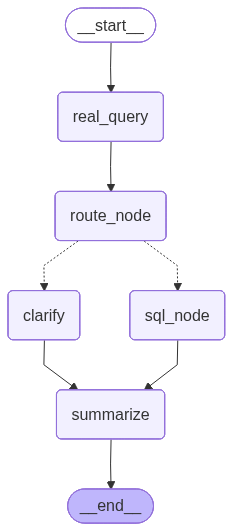

In [27]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
def format_qa_for_excel(qa_list):
    blocks = []
    for i, item in enumerate(qa_list, 1):
        q = item.get("Q", "")
        a = item.get("A", {}).get("content", "")
        blocks.append(f"Q{i}：{q}\nA{i}：{a}")
    return "\n\n".join(blocks)

def rename_images_for_row(image_list, row_id, start_index=1, out_dir="./result"):
    image_list = normalize_image_list(image_list)
    if not image_list:
        return [], start_index

    os.makedirs(out_dir, exist_ok=True)
    renamed_paths = []
    current_index = start_index

    for old_path in image_list:
        ext = os.path.splitext(old_path)[1] or ".png"
        new_name = f"{row_id}_{current_index}{ext}"
        new_path = os.path.join(out_dir, new_name)

        if os.path.abspath(old_path) != os.path.abspath(new_path):
            os.replace(old_path, new_path)

        renamed_paths.append(new_path)
        current_index += 1

    return renamed_paths, current_index

In [27]:
import ast
import json
import uuid
import pandas as pd


def parse_question_cell(cell):
    """
    解析 Excel 中“问题”列
    支持：
    1. 普通字符串
    2. JSON 字符串
    3. Python 列表字符串
    返回：问题列表，如 ["问题1", "问题2"]
    """
    if pd.isna(cell):
        return []

    if isinstance(cell, list):
        raw = cell
    else:
        text = str(cell).strip()
        if not text:
            return []

        if text.startswith("[") and text.endswith("]"):
            try:
                raw = json.loads(text)   # 先直接按原文本解析
            except Exception:
                try:
                    safe_text = (
                        text.replace("‘", "'")
                            .replace("’", "'")
                    )
                    raw = ast.literal_eval(safe_text)
                except Exception:
                    return [text]
        else:
            return [text]

    questions = []
    for item in raw:
        if isinstance(item, dict):
            q = item.get("Q") or item.get("q") or item.get("question")
            if q and str(q).strip():
                questions.append(str(q).strip())
        elif isinstance(item, str):
            if item.strip():
                questions.append(item.strip())

    return questions


def normalize_image_list(x):
    """
    统一把 image / image_path 转成 list[str]
    """
    if x is None:
        return []
    if isinstance(x, list):
        return [str(i) for i in x if str(i).strip()]
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        try:
            val = json.loads(s)
            if isinstance(val, list):
                return [str(i) for i in val if str(i).strip()]
            return [s]
        except Exception:
            return [s]
    return []


def detect_chart_type(question, image_list):
    """
    根据问题内容和是否有图，给出图形格式
    你现在先用最简单稳定的规则：
    - 没图：无
    - 有图且问题包含趋势/走势/变化：折线图
    - 有图且问题包含占比/构成：饼图
    - 其他有图：图表
    """
    if not image_list:
        return "无"

    q = str(question)
    if any(k in q for k in ["趋势", "走势", "变化", "历年", "近几年", "近年"]):
        return "折线图"
    if any(k in q for k in ["占比", "构成"]):
        return "饼图"
    if any(k in q for k in ["对比", "比较", "排名"]):
        return "柱状图"

    return "图表"

import re

def markdown_to_plain_text(text: str) -> str:
    if not text:
        return ""

    text = str(text).replace("\r\n", "\n")

    # 去掉粗体、标题、行内代码
    text = text.replace("**", "").replace("__", "")
    text = re.sub(r"`([^`]*)`", r"\1", text)
    text = re.sub(r"^\s{0,3}#{1,6}\s*", "", text, flags=re.M)

    # 去掉列表符号
    text = re.sub(r"^\s*[-*+]\s+", "", text, flags=re.M)

    lines = text.split("\n")
    result = []
    i = 0

    while i < len(lines):
        line = lines[i].strip()

        # 识别 markdown 表格
        if line.startswith("|") and line.endswith("|"):
            table_block = []
            while i < len(lines):
                cur = lines[i].strip()
                if cur.startswith("|") and cur.endswith("|"):
                    table_block.append(cur)
                    i += 1
                else:
                    break

            # 表头 + 分隔线 + 数据
            if len(table_block) >= 3:
                headers = [x.strip() for x in table_block[0].strip("|").split("|")]
                for row in table_block[2:]:
                    cells = [x.strip() for x in row.strip("|").split("|")]
                    if len(cells) == len(headers):
                        result.append("，".join(f"{h}：{c}" for h, c in zip(headers, cells)))
            else:
                # 不是标准表格时，粗暴去掉 |
                for row in table_block:
                    row = row.replace("|", " ").strip()
                    if row:
                        result.append(row)
            continue

        # 跳过表格分隔线
        if re.fullmatch(r"\|?[\-\:\s\|]+\|?", line):
            i += 1
            continue

        if line:
            # 顺手把多余的 | 去掉
            line = line.replace("|", " ")
            result.append(line)

        i += 1

    return "\n".join(result).strip()

def run_one_turn(question, thread_id, question_count=1):
    """
    执行单轮问答，并提取当前轮需要写入 Excel 的核心信息
    """
    skip_summary = (question_count == 1)

    config = {"configurable": {"thread_id": thread_id}}
    inputs = {
        "messages": [
            {
                "role": "user",
                "content": question,
            }
        ],
        "query": question,
        "question_count": question_count,
        "skip_summary": skip_summary,
    }

    for _ in graph.stream(inputs, config):
        pass

    state = graph.get_state(config).values

    sql_result = state.get("sql_result") or {}

    sql_query = (
        sql_result.get("query")
        or sql_result.get("sql")
        or state.get("sql_query")
        or ""
    )
    
    sql_query = str(sql_query).replace("\r", " ").replace("\n", " ")
    sql_query = re.sub(r"\s+", " ", sql_query).strip()

    answer_text = (
        state.get("final_answer")
        or sql_result.get("answer")
        or ""
    )
    
    chart_format = sql_result.get("chart_format", "无")
    
    answer_text = markdown_to_plain_text(answer_text)
    answer_text = answer_text.replace("\n", " ").replace("\r", " ")
    answer_text = re.sub(r"\s+", " ", answer_text).strip()

    image_list = normalize_image_list(
        sql_result.get("image_path")
    )

    answer_obj = {
        "content": answer_text
    }
    if image_list:
        answer_obj["image"] = image_list

    return {
        "Q": question,
        "A": answer_obj,
        "route": state.get("route", ""),
        "sql_query": sql_query,
        "image_list": image_list,
        "chart_format": chart_format,
    }


def run_excel_batch(
    xlsx_path,
    sheet_name=0,
    id_col="编号",
    question_col="问题",
    output_path="./result/批量问答结果.xlsx"
):
    """
    输出格式与截图一致：
    编号 | 问题 | SQL 查询语句 | 图形格式 | 回答
    """
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name)
    df.columns = [str(c).strip() for c in df.columns]

    if id_col not in df.columns:
        raise ValueError(f"Excel 中未找到列：{id_col}，当前列名：{df.columns.tolist()}")
    if question_col not in df.columns:
        raise ValueError(f"Excel 中未找到列：{question_col}，当前列名：{df.columns.tolist()}")

    batch_tag = uuid.uuid4().hex[:8]
    result_rows = []

    for _, row in df.iterrows():
        row_id = str(row[id_col]).strip()
        question_list = parse_question_cell(row[question_col])

        if not question_list:
            result_rows.append({
                "编号": row_id,
                "问题": "",
                "SQL 查询语句": "",
                "图形格式": "无",
                "回答": "",
            })
            continue

        thread_id = f"excel_{batch_tag}_{row_id}"

        qa_list = []
        last_sql = ""
        final_chart_format = "无"
        final_images = []
        image_counter = 1

        try:
            question_count = len(question_list)

            for q in question_list:
                turn_result = run_one_turn(
                    q,
                    thread_id,
                    question_count=question_count
                )

                if turn_result["sql_query"]:
                    last_sql = turn_result["sql_query"]
                
                if turn_result.get("chart_format") and turn_result["chart_format"] != "无":
                    final_chart_format = turn_result["chart_format"]

                if turn_result["image_list"]:
                    renamed_images, image_counter = rename_images_for_row(
                        turn_result["image_list"],
                        row_id=row_id,
                        start_index=image_counter,
                        out_dir="./result"
                    )

                    # 把当前轮返回的图片路径改成重命名后的路径
                    turn_result["image_list"] = renamed_images

                    # 同时把写入“回答”里的 image 字段也改掉
                    if "A" in turn_result and isinstance(turn_result["A"], dict):
                        turn_result["A"]["image"] = renamed_images

#                     final_images = renamed_images
                    final_images.extend(renamed_images)
                    
                qa_list.append({
                    "Q": turn_result["Q"],
                    "A": turn_result["A"]
                })

            result_rows.append({
                "编号": row_id,
                "问题": json.dumps([{"Q": q} for q in question_list], ensure_ascii=False),
                "SQL 查询语句": last_sql,
                "图形格式": final_chart_format,
                "回答": json.dumps(qa_list, ensure_ascii=False, indent=2),
            })

        except Exception as e:
            result_rows.append({
                "编号": row_id,
                "问题": json.dumps([{"Q": q} for q in question_list], ensure_ascii=False),
                "SQL 查询语句": "",
                "图形格式": "无",
                "回答": json.dumps(
                    [{"Q": "系统异常", "A": {"content": str(e)}}],
                    ensure_ascii=False
                ),
            })

    result_df = pd.DataFrame(result_rows)
    result_df.to_excel(output_path, index=False)
    print(f"批量问答完成，结果保存到：{output_path}")
    return result_df

In [ ]:
import time

start = time.time()

result_df = run_excel_batch(
    xlsx_path=r"附件4：问题汇总.xlsx",
    sheet_name=0,
    id_col="编号",
    question_col="问题",
    output_path=r"任务二批量问答结果.xlsx"
)

end = time.time()
print("运行时间：", end - start, "秒")

----------------------------------------------------------------------------------------------------
Summary
【更新后记忆】

- 用户目标：查询金花股份的利润总额
- 待确认信息：具体报告期（年报/季报/半年报，年份）未明确
- 下一步：询问用户所需的具体报告期
----------------------------------------------------------------------------------------------------


In [28]:
import json
import time

q = "华润三九近几年的每股收益的变化趋势"

start = time.time()

res = run_one_turn(
    question=q,
    thread_id="single_test_000",
    question_count=1
)

end = time.time()

print("运行时间：", end - start, "秒")
print(json.dumps(res, ensure_ascii=False, indent=2))

question = 华润三九近几年的每股收益的变化趋势
df.columns = ['report_year', 'eps']
df.head =
   report_year   eps
0        2022  2.48
1        2023   2.9
2        2024  2.63
chart_plan = need_chart=True chart_type='line' x_col='report_year' y_col='eps' y_col2='' series_col='' title='华润三九近几年每股收益变化趋势' reason='用户询问每股收益的变化趋势，且数据包含年份和每股收益两个字段，适合用折线图展示时间序列趋势'
运行时间： 11.315119743347168 秒
{
  "Q": "华润三九近几年的每股收益的变化趋势",
  "A": {
    "content": "华润三九近几年的每股收益呈现先升后降的波动趋势。2022年每股收益为2.48元，2023年上升至2.90元，同比增长约16.9%，达到近三年高点。2024年每股收益回落至2.63元，较2023年下降约9.3%，但仍高于2022年水平。整体来看，2022年至2023年实现明显增长，但2024年出现回调，三年间累计增幅约为6.0%。",
    "image": [
      "./result/sql_plot_f5b92a92.png"
    ]
  },
  "route": "sql",
  "sql_query": "SELECT report_year, eps FROM core WHERE stock_abbr = '华润三九' AND report_period = 'FY' ORDER BY report_year ASC",
  "image_list": [
    "./result/sql_plot_f5b92a92.png"
  ],
  "chart_format": "折线图"
}


In [28]:
import time

start = time.time()

result_df = run_excel_batch(
    xlsx_path=r"新建 XLSX 工作表.xlsx",
    sheet_name=0,
    id_col="编号",
    question_col="问题",
    output_path=r"任务二问答结果1.xlsx"
)

end = time.time()
print("运行时间：", end - start, "秒")

question = 金花股份近几年的利润总额变化趋势是什么样的
df.columns = ['report_year', 'total_profit']
df.head =
    report_year  total_profit
0         2022   47900957.84
1         2023  -41054617.26
2         2024   42039280.14
chart_plan = need_chart=True chart_type='line' x_col='report_year' y_col='total_profit' y_col2='' series_col='' title='金花股份近几年利润总额变化趋势' reason="用户询问'变化趋势'，且数据包含年份和利润总额两个字段，适合使用折线图展示时间序列趋势"


PermissionError: [Errno 13] Permission denied: '任务二问答结果1.xlsx'

In [28]:
import time

q = "计算2025年第三季度66家公司的净利润中位数，找出净利润高于中位数且销售毛利率低于行业均值的公司，列出股票代码、简称、净利润、销售毛利率。"


start = time.time()

res = run_one_turn(
    question=q,
    thread_id="single_test_002",
    question_count=1
)

end = time.time()

print("运行时间：", end - start, "秒")
print(json.dumps(res, ensure_ascii=False, indent=2))

question = 计算2025年第三季度66家公司的净利润中位数，找出净利润高于中位数且销售毛利率低于行业均值的公司，列出股票代码、简称、净利润、销售毛利率。
df.columns = ['company_count', 'industry_avg_gross_margin', 'median_net_profit']
df.head =
    company_count  industry_avg_gross_margin  median_net_profit
0             55                  51.389091        27209399.91
chart_plan = need_chart=False chart_type='none' x_col='' y_col='' y_col2='' series_col='' title='' reason='SQL查询结果仅包含统计汇总数据（公司数量、行业平均毛利率、净利润中位数），没有具体公司的股票代码、简称、净利润、销售毛利率等明细数据，无法绘制图表。用户问题要求列出具体公司信息，但返回的数据是聚合统计值，数据不匹配，不适合可视化。'
运行时间： 49.3842351436615 秒
{
  "Q": "计算2025年第三季度66家公司的净利润中位数，找出净利润高于中位数且销售毛利率低于行业均值的公司，列出股票代码、简称、净利润、销售毛利率。",
  "A": {
    "content": "根据2025年第三季度数据，共有55家公司（非66家）披露完整数据。经计算，净利润中位数为2720.94万元，行业平均销售毛利率为51.39%。 满足净利润高于中位数且销售毛利率低于行业均值的公司共9家，具体名单如下： 云南白药（000538）：净利润114420.84万元，销售毛利率30.06% 片仔癀（600436）：净利润68703.84万元，销售毛利率35.08% 同仁堂（600085）：净利润23205.70万元，销售毛利率42.69% 马应龙（600993）：净利润15778.84万元，销售毛利率48.00% 仁和药业（000650）：净利润8870.89万元，销售毛利率36.43% 精华制药（002349）：净利润4572.83万元，销售毛利率50.73% 信邦

In [29]:
import time

q = "2025年第三季度，“投资性现金流量净额”为正数（即投资现金流入大于流出）的公司有多少家？请列出其中营收排名前三的公司简称及投资现金流净额（万元）"


start = time.time()

res = run_one_turn(
    question=q,
    thread_id="single_test_000",
    question_count=1
)

end = time.time()

print("运行时间：", end - start, "秒")
print(json.dumps(res, ensure_ascii=False, indent=2))

question = 2025年第三季度，“投资性现金流量净额”为正数（即投资现金流入大于流出）的公司有多少家？请列出其中营收排名前三的公司简称及投资现金流净额（万元）
df.columns = ['stock_abbr', 'investing_cf_net_amount']
df.head =
   stock_abbr  investing_cf_net_amount
0       华润三九             1.622216e+08
1        片仔癀             1.435581e+09
2        天士力             7.226896e+08
chart_plan = need_chart=True chart_type='bar' x_col='stock_abbr' y_col='investing_cf_net_amount' y_col2='' series_col='' title='2025年Q3投资性现金流量净额为正的前三公司' reason='用户要求列出营收排名前三的公司简称及投资现金流净额，属于类别比较场景，适合用柱状图展示；数据包含公司名称和单一数值指标，x_col选stock_abbr，y_col选investing_cf_net_amount'
运行时间： 23.162939071655273 秒
{
  "Q": "2025年第三季度，“投资性现金流量净额”为正数（即投资现金流入大于流出）的公司有多少家？请列出其中营收排名前三的公司简称及投资现金流净额（万元）",
  "A": {
    "content": "2025年第三季度，投资性现金流量净额为正数的公司共有13家。 其中营收排名前三的公司及其投资现金流净额（万元）如下： 1. 片仔癀：143558.13万元 2. 天士力：72268.96万元 3. 华润三九：16222.16万元",
    "image": [
      "./result/sql_plot_8fe9b148.png"
    ]
  },
  "route": "sql",
  "sql_query": "SELECT c.stock_abbr, c.investing_cf_net_amount FROM cash c JOIN core r ON

In [30]:
import time

q = "云南白药（000538）2025年第三季度的“营业总收入环比增长率”与2024年第三季度的环比增长率相比，变化了多少？请展示两年同期的环比数据。"


start = time.time()

res = run_one_turn(
    question=q,
    thread_id="single_test_003",
    question_count=1
)

end = time.time()

print("运行时间：", end - start, "秒")
print(json.dumps(res, ensure_ascii=False, indent=2))

question = 云南白药（000538）2025年第三季度的“营业总收入环比增长率”与2024年第三季度的环比增长率相比，变化了多少？请展示两年同期的环比数据。
df.columns = ['report_year', 'report_period', 'operating_revenue_qoq_growth']
df.head =
   report_year report_period operating_revenue_qoq_growth
0        2024            Q3                       -2.28%
1        2025            Q3                       -9.78%
chart_plan = need_chart=True chart_type='double_bar' x_col='report_year' y_col='operating_revenue_qoq_growth' y_col2='' series_col='' title='云南白药2024年与2025年Q3营业总收入环比增长率对比' reason='用户要求对比两年同期的环比数据，适合用双柱状图展示2024年Q3和2025年Q3的营业总收入环比增长率，便于直观比较变化幅度'
运行时间： 28.25469136238098 秒
{
  "Q": "云南白药（000538）2025年第三季度的“营业总收入环比增长率”与2024年第三季度的环比增长率相比，变化了多少？请展示两年同期的环比数据。",
  "A": {
    "content": "云南白药（000538）2024年第三季度营业总收入环比增长率为-2.28%，2025年第三季度营业总收入环比增长率为-9.78%。 两年同期环比增长率相比，2025年第三季度较2024年第三季度下降了7.50个百分点（从-2.28%降至-9.78%），环比增速进一步放缓，显示公司季度间营收增长动力有所减弱。"
  },
  "route": "sql",
  "sql_query": "SELECT report_year, report_period, operating_revenue_qoq_growth FROM core WHERE 

In [31]:
import time

q = "2025年前三季度，公司实现收入超过200亿元的企业有哪些。"


start = time.time()

res = run_one_turn(
    question=q,
    thread_id="single_test_003",
    question_count=1
)

end = time.time()

print("运行时间：", end - start, "秒")
print(json.dumps(res, ensure_ascii=False, indent=2))

question = 2025年前三季度，公司实现收入超过200亿元的企业有哪些。
df.columns = ['stock_code', 'stock_abbr', 'total_operating_revenue']
df.head =
   stock_code stock_abbr  total_operating_revenue
0     600332        白云山             6.160599e+10
1     000538       云南白药             3.065421e+10
chart_plan = need_chart=True chart_type='bar' x_col='stock_abbr' y_col='total_operating_revenue' y_col2='' series_col='' title='2025年前三季度收入超200亿元企业' reason='用户查询的是收入超过200亿元的企业名单，属于排名/类别比较场景，适合用柱状图展示各企业收入规模对比'
运行时间： 9.560283660888672 秒
{
  "Q": "2025年前三季度，公司实现收入超过200亿元的企业有哪些。",
  "A": {
    "content": "2025年前三季度，营业收入超过200亿元的企业有2家。 白云山（600332）2025年前三季度实现营业收入616.06亿元，云南白药（000538）2025年前三季度实现营业收入306.54亿元。这两家企业均属于医药制造行业，营收规模在行业内处于领先地位。",
    "image": [
      "./result/sql_plot_59db3c90.png"
    ]
  },
  "route": "sql",
  "sql_query": "SELECT stock_code, stock_abbr, total_operating_revenue FROM income WHERE report_year = '2025' AND report_period = 'Q3' AND total_operating_revenue > 20000000000 ORDER BY total_operating_revenue DE

In [32]:
import time

q = "2025年第三季度，“核心业绩指标表”中的“营业总收入”与“利润表”中的“营业总收入”不一致的公司有哪些？请列出股票代码及两个表中的数值。"


start = time.time()

res = run_one_turn(
    question=q,
    thread_id="single_test_004",
    question_count=1
)

end = time.time()

print("运行时间：", end - start, "秒")
print(json.dumps(res, ensure_ascii=False, indent=2))

question = 2025年第三季度，“核心业绩指标表”中的“营业总收入”与“利润表”中的“营业总收入”不一致的公司有哪些？请列出股票代码及两个表中的数值。
df.columns = ['stock_code', 'stock_abbr', 'core_revenue', 'income_revenue']
df.head =
   stock_code stock_abbr   core_revenue  income_revenue
0     000989        九芝堂   362940886.72    1.627453e+09
1     000538       云南白药  9397111312.99    3.065421e+10
2     000650       仁和药业    858360283.9    2.833452e+09
3     002603       以岭药业  1827460855.67    5.867603e+09
4     002317       众生药业   589023962.64    1.888754e+09
chart_plan = need_chart=True chart_type='double_bar' x_col='stock_abbr' y_col='core_revenue' y_col2='income_revenue' series_col='' title='2025年Q3核心业绩指标表与利润表营业总收入对比' reason='用户需要对比两个表中营业总收入不一致的公司，适合用双条形图并列展示同一公司两个来源的数值，便于直观比较差异'
运行时间： 26.353861570358276 秒
{
  "Q": "2025年第三季度，“核心业绩指标表”中的“营业总收入”与“利润表”中的“营业总收入”不一致的公司有哪些？请列出股票代码及两个表中的数值。",
  "A": {
    "content": "2025年第三季度，\"核心业绩指标表\"与\"利润表\"中\"营业总收入\"数据不一致的公司共有5家，具体情况如下： 股票代码000989（九芝堂）：核心业绩指标表显示营业总收入为362940886.72元，利润表显示为1627453256.26元，两者差异约12.65亿元。 

In [33]:
import time

q = "999与白云山相比，去年收益率最高的是"


start = time.time()

res = run_one_turn(
    question=q,
    thread_id="single_test_004",
    question_count=1
)

end = time.time()

print("运行时间：", end - start, "秒")
print(json.dumps(res, ensure_ascii=False, indent=2))

question = 999与白云山相比，去年收益率最高的是
df.columns = ['stock_code', 'stock_abbr', 'report_year', 'report_period', 'roe']
df.head =
   stock_code stock_abbr report_year report_period     roe
0     000999       华润三九        2024            FY  17.33%
1     600332        白云山        2024            FY    7.99
chart_plan = need_chart=True chart_type='bar' x_col='stock_abbr' y_col='roe' y_col2='' series_col='' title='华润三九与白云山2024年ROE对比' reason='用户问题要求比较两只股票（999/华润三九与白云山）的收益率，数据包含两只股票的ROE数值，适合用柱状图进行类别比较，直观展示哪家收益率更高'
运行时间： 19.105886936187744 秒
{
  "Q": "999与白云山相比，去年收益率最高的是",
  "A": {
    "content": "根据查询结果，华润三九（000999）2024年净资产收益率（ROE）为17.33%，白云山（600332）2024年净资产收益率为7.99%。因此，去年收益率最高的是华润三九（000999），其ROE为17.33%，高于白云山的7.99%。",
    "image": [
      "./result/sql_plot_a794c8fd.png"
    ]
  },
  "route": "sql",
  "sql_query": "SELECT stock_code, stock_abbr, report_year, report_period, roe FROM core WHERE (stock_code = '000999' OR stock_abbr LIKE '%白云山%') AND report_year = '2024' AND report_period = 'FY'",
  "ima

In [29]:
import time

q = "对比2025年第三季度研发费用占比前十与后十公司的净利润同比增长率，用箱线图展示两组数据的分布差异"


start = time.time()

res = run_one_turn(
    question=q,
    thread_id="single_test_004",
    question_count=1
)

end = time.time()

print("运行时间：", end - start, "秒")
print(json.dumps(res, ensure_ascii=False, indent=2))

question = 对比2025年第三季度研发费用占比前十与后十公司的净利润同比增长率，用箱线图展示两组数据的分布差异
df.columns = ['stock_code', 'stock_abbr', 'rnd_ratio', 'net_profit_yoy_growth', 'net_profit_yoy_growth_num', 'group_label']
df.head =
   stock_code stock_abbr  rnd_ratio net_profit_yoy_growth  \
0     600613       神奇制药   0.018102         -93548001.02%   
1     600085        同仁堂   0.014740        -786900624.48%   
2     603139       康惠制药   0.012897              -211.97%   
3     600518       康美药业   0.010693          -2374559.43%   
4     301331       恩威医药   0.009401              -143.05%   

   net_profit_yoy_growth_num group_label  
0              -9.354800e+07    Bottom10  
1              -7.869006e+08    Bottom10  
2              -2.119700e+02    Bottom10  
3              -2.374559e+06    Bottom10  
4              -1.430500e+02    Bottom10  
chart_plan = need_chart=True chart_type='box' x_col='group_label' y_col='net_profit_yoy_growth_num' y_col2='' series_col='' title='2025年Q3研发费用占比前十与后十公司净利润同比增长率分布对比' reason='用户明确要求使用箱线图展

C:\Users\cr\AppData\Local\Temp\ipykernel_37412\1959141044.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=labels)
